# 43 · NIAMS · bulk_RNA_seq · PRE samples: SAVI against CANDLE

Reads `counts_raw.rds`, `counts_combatseq.rds` and `samples.rds` (notebook 40). Writes `de_NIAMS_PRE_SAVI-CANDLE.csv`
and `top_genes_NIAMS_PRE_SAVI-CANDLE.csv` in `data/run_artifacts/CANDLE_SAVI/`, and a heatmap to
`figures/CANDLE_SAVI/`.

**Samples.** The NIAMS samples with Treatment = PRE, from the 161 samples of notebook 40: CANDLE and SAVI.

**Method.** As in notebook 41: raw counts, limma-voom (Law CW et al. *Genome Biol* 2014;15:R29) with the
patient as a blocking factor (`duplicateCorrelation`; Smyth GK, Michaud J, Scott HS. *Bioinformatics*
2005;21:2067-2075); design `~ 0 + diagnosis + batch`, where batch is the NIAMS sequencing cohort. Top genes:
adjusted p < 0.05 and fold change at least 2.

**Heatmap.** As in notebook 42: the ComBat-seq counts of notebook 40, log2 counts per million, z-scored per
gene; Ward trees on both axes.

## PRE samples

In [1]:
source("../src/paths.R")
suppressMessages({library(limma); library(edgeR); library(ComplexHeatmap); library(circlize)})
x <- readRDS(art("CANDLE_SAVI", "counts_raw.rds")); s <- readRDS(art("CANDLE_SAVI", "samples.rds"))
pre <- s[s$Sequencing_Facility == "NIAMS" & s$Treatment == "PRE", ]
table(diagnosis = pre$diagnosis, batch = pre$batch)
c(samples = nrow(pre), patients = length(unique(pre$patient)))

         batch
diagnosis NIAMS-Batch1 NIAMS-unlabelled
   CANDLE           23                8
   SAVI             12                1

samples patients 
      44       16

**Explanation**
- `pre` keeps the NIAMS samples whose Treatment is PRE.
- The table crosses diagnosis with the NIAMS sequencing cohort; the last line counts samples and patients.

**Result.** 44 PRE samples from 16 patients: CANDLE 31 (Batch1 23, unlabelled 8), SAVI 13 (Batch1 12,
unlabelled 1).

## limma-voom with the patient as a block

In [2]:
pre$diagnosis <- factor(make.names(pre$diagnosis)); pre$batch <- factor(make.names(pre$batch))
design <- model.matrix(~ 0 + diagnosis + batch, pre); colnames(design) <- sub("^diagnosis", "", colnames(design))
dge  <- DGEList(x$counts[, pre$sample], genes = x$genes)
keep <- filterByExpr(dge, design); dge <- calcNormFactors(dge[keep, , keep.lib.sizes = FALSE])
v    <- voom(dge, design)
cor1 <- duplicateCorrelation(v, design, block = pre$patient)$consensus
v    <- voom(dge, design, block = pre$patient, correlation = cor1)
cor2 <- duplicateCorrelation(v, design, block = pre$patient)$consensus
fit  <- eBayes(contrasts.fit(lmFit(v, design, block = pre$patient, correlation = cor2),
                             makeContrasts(SAVI - CANDLE, levels = design)))
tab  <- topTable(fit, coef = 1, number = Inf, sort.by = "P")
top  <- tab[tab$adj.P.Val < 0.05 & abs(tab$logFC) >= 1, c("gene_id", "gene_name", "logFC", "AveExpr", "adj.P.Val")]
c(genes_kept = sum(keep), correlation = round(cor2, 3), adj_p_below_0.05 = sum(tab$adj.P.Val < 0.05),
  top_up = sum(top$logFC > 0), top_down = sum(top$logFC < 0))
write.csv(tab, art("CANDLE_SAVI", "de_NIAMS_PRE_SAVI-CANDLE.csv"), row.names = FALSE)
write.csv(top, art("CANDLE_SAVI", "top_genes_NIAMS_PRE_SAVI-CANDLE.csv"), row.names = FALSE)
print(head(transform(top, logFC = round(logFC, 2), AveExpr = round(AveExpr, 1), adj.P.Val = signif(adj.P.Val, 2)), 15), row.names = FALSE)

genes_kept      correlation adj_p_below_0.05           top_up 
       23508.000            0.156          153.000           66.000 
        top_down 
          28.000

         gene_id    gene_name logFC AveExpr adj.P.Val
 ENSG00000263155        MYZAP  2.01     0.9   0.00067
 ENSG00000151650        VENTX  1.98     2.1   0.00067
 ENSG00000051128       HOMER3  1.61     2.8   0.00220
 ENSG00000188487         INSC  2.29     0.1   0.00550
 ENSG00000164512      ANKRD55 -1.06     3.8   0.00550
 ENSG00000085449        WDFY1 -1.30     6.2   0.00560
 ENSG00000154856       APCDD1  1.54     0.2   0.00560
 ENSG00000237568 RP4-620F22.2 -1.92     8.8   0.00580
 ENSG00000154451         GBP5 -1.90     9.4   0.00580
 ENSG00000103154       NECAB2  1.79     2.0   0.00870
 ENSG00000100505        TRIM9  2.25     1.6   0.00870
 ENSG00000100079       LGALS2  2.07     2.7   0.00870
 ENSG00000262001   DLGAP1-AS2  1.18     1.6   0.00930
 ENSG00000019102        VSIG2  1.98     1.9   0.00930
 ENSG00000111452       GPR133  1.70     0.7   0.01100


**Explanation**
- The design, filter, voom, `duplicateCorrelation` and fit are those of notebook 41, on the PRE samples only.
- `makeContrasts(SAVI - CANDLE, levels = design)` is the one comparison: a positive log2 fold change means
  higher in SAVI.
- `top` keeps the genes with adjusted p < 0.05 and |log2 fold change| >= 1; the full table and the top genes
  are written as CSV files, and the 15 top genes with the smallest adjusted p are printed.

**Result.** 23,508 genes pass the filter; the correlation between samples of the same patient is 0.156. 153
genes have adjusted p < 0.05; 94 of them also have a fold change of at least 2: 66 higher in SAVI and 28
higher in CANDLE. Higher in CANDLE are, among others, GBP5, WDFY1 and ANKRD55; higher in SAVI MYZAP, VENTX,
HOMER3, INSC, APCDD1 and TRIM9. INSC, APCDD1 and TRIM9 are also among the top genes of SAVI against CANDLE over
all samples (notebook 41).

## Heatmap

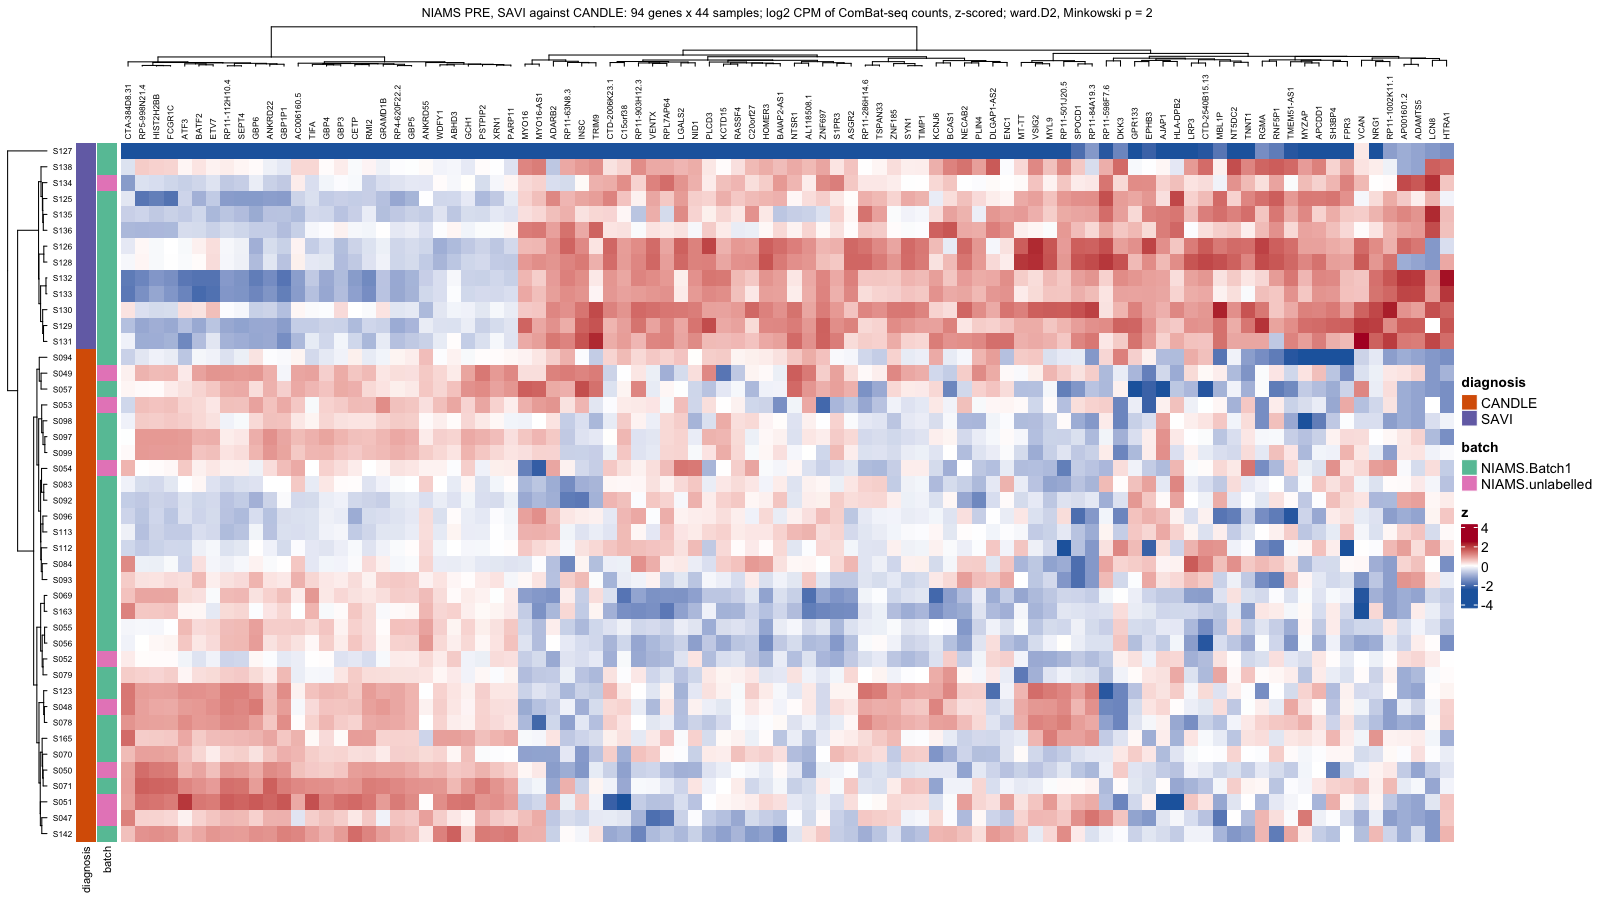

      diagnosis
branch CANDLE SAVI
     1     31   12
     2      0    1

In [3]:
xc <- readRDS(art("CANDLE_SAVI", "counts_combatseq.rds"))
logcpm <- cpm(calcNormFactors(DGEList(xc$counts[, pre$sample])), log = TRUE)
H  <- scale(t(logcpm[top$gene_id, , drop = FALSE])); H <- H[, colSums(is.na(H)) == 0, drop = FALSE]
Hc <- pmin(pmax(H, -2.5), 2.5)
hr <- hclust(dist(H, method = "minkowski", p = 2), method = "ward.D2")
hc <- hclust(dist(t(H), method = "minkowski", p = 2), method = "ward.D2")
left <- rowAnnotation(diagnosis = as.character(pre$diagnosis), batch = as.character(pre$batch),
                      col = list(diagnosis = c(CANDLE = "#D95F02", SAVI = "#7570B3"),
                                 batch = c(NIAMS.Batch1 = "#66C2A5", NIAMS.unlabelled = "#E78AC3")),
                      annotation_name_gp = gpar(fontsize = 8))
ht <- Heatmap(Hc, name = "z", col = colorRamp2(c(-2.5, 0, 2.5), c("#2166AC", "white", "#B2182B")),
              cluster_rows = hr, cluster_columns = hc, row_dend_side = "left", column_dend_side = "top", column_names_side = "top", row_names_side = "left",
              row_names_gp = gpar(fontsize = 6),
              column_labels = top$gene_name[match(colnames(H), top$gene_id)], column_names_gp = gpar(fontsize = 6),
              left_annotation = left, column_title_gp = gpar(fontsize = 9),
              column_title = sprintf("NIAMS PRE, SAVI against CANDLE: %d genes x %d samples; log2 CPM of ComBat-seq counts, z-scored; ward.D2, Minkowski p = 2", ncol(H), nrow(H)))
for (res in c(300, 100)) {                          # a 300 dpi PNG kept, a 100 dpi copy shown here
  f <- if (res == 300) fig("CANDLE_SAVI", "43_heatmap_NIAMS_PRE.png") else tempfile(fileext = ".png")
  png(f, width = 16, height = 9, units = "in", res = res); draw(ht); invisible(dev.off())
}
IRdisplay::display_png(file = f)
table(branch = cutree(hr, 2), diagnosis = pre$diagnosis)

**Explanation**
- The ComBat-seq counts of the PRE samples, log2 counts per million, z-scored per top gene; colours capped at
  -2.5 and 2.5.
- `hr` and `hc` are Ward trees of the samples and the genes; the strips show diagnosis and cohort.
- The heatmap is saved at 300 dpi and shown at 100 dpi, as in notebook 42.
- `cutree(hr, 2)` gives the first split of the sample tree; the table crosses it with diagnosis.

**Result.** The first split of the sample tree sets one SAVI sample, S127, apart from the other 43 (the
sample also apart in notebook 40). The other 12 SAVI samples and the 31 CANDLE samples share the second
branch.

## The 28 interferon response genes and the 11 NF-kB-only controls

In [4]:
GENES <- xc$genes
irg <- read_gene_set("ifn-response-genes-28.txt"); nfk <- read_gene_set("nfkb-only-control-11-dejesus2020.txt")
dj3 <- read_gene_set("ifn-response-genes-3-stat1-nfkb-dejesus2020.txt")
ifn <- data.frame(gene_name = c(irg, nfk), set = rep(c("IRG-28", "NF-kB-11"), c(length(irg), length(nfk))))
ifn$subscore <- ifelse(ifn$set == "NF-kB-11", "control", ifelse(ifn$gene_name %in% dj3, "3 STAT1/NF-kB", "25 STAT1-only"))
ifn$gene_id  <- GENES$gene_id[match(ifn$gene_name, GENES$gene_name)]
ifn_heat <- function(logcpm, left, title) {
  g  <- ifn[!is.na(ifn$gene_id), ]
  H  <- scale(t(logcpm[g$gene_id, , drop = FALSE])); keep <- colSums(is.na(H)) == 0
  H  <- H[, keep, drop = FALSE]; g <- g[keep, ]; Hc <- pmin(pmax(H, -2.5), 2.5)
  hr <- hclust(dist(H, method = "minkowski", p = 2), method = "ward.D2")
  hc <- hclust(dist(t(H), method = "minkowski", p = 2), method = "ward.D2")
  top_ann <- HeatmapAnnotation(set = g$set, subscore = g$subscore,
                               col = list(set = c("IRG-28" = "#B2182B", "NF-kB-11" = "grey40"),
                                          subscore = c("25 STAT1-only" = "steelblue", "3 STAT1/NF-kB" = "firebrick", control = "grey80")),
                               annotation_name_side = "left", annotation_name_gp = gpar(fontsize = 8))
  ht <- Heatmap(Hc, name = "z", col = colorRamp2(c(-2.5, 0, 2.5), c("#2166AC", "white", "#B2182B")),
                cluster_rows = hr, cluster_columns = hc, row_dend_side = "left", column_dend_side = "top",
                row_names_side = "left", row_names_gp = gpar(fontsize = 5), column_labels = g$gene_name,
                column_names_side = "top", column_names_gp = gpar(fontsize = 8),
                top_annotation = top_ann, left_annotation = left, column_title_gp = gpar(fontsize = 9),
                column_title = sprintf("%s: 28 interferon response genes and 11 NF-kB-only controls x %d samples; log2 CPM of ComBat-seq counts, z-scored; ward.D2, Minkowski p = 2", title, nrow(H)))
  list(ht = ht, rows = hr, cols = hc, genes = g)
}
c(interferon_genes_found = sum(!is.na(ifn$gene_id[ifn$set == "IRG-28"])), control_genes_found = sum(!is.na(ifn$gene_id[ifn$set == "NF-kB-11"])))

interferon_genes_found    control_genes_found 
                    28                     11

**Explanation**
- The gene lists are those of notebooks 05c, 15c and 26c (`genes/`, see notebook 00 for `read_gene_set()`):
  - `ifn-response-genes-28.txt`: the 28 interferon response genes listed in Kim H et al. *J Interferon
    Cytokine Res* 2018;38:171-185 (Supplementary Table S1) and in de Jesus AA et al. *J Clin Invest*
    2020;130:1669-1682 (Supplemental Figure 3B);
  - `ifn-response-genes-3-stat1-nfkb-dejesus2020.txt`: CXCL10, GBP1 and SOCS1, which de Jesus 2020 separates
    as genes with STAT1 and NF-kB binding sites; the other 25 are STAT1-only;
  - `nfkb-only-control-11-dejesus2020.txt`: 11 NF-kB target genes with no STAT1, STAT2 or TYK1 binding site,
    the control (de Jesus 2020).
- `ifn` lists the 39 genes with their set and subscore; `gene_id` finds each gene's Ensembl identifier by its
  name in these data.
- `ifn_heat(logcpm, left, title)` draws the heatmap: samples as rows, genes as columns, each gene z-scored,
  colours capped at -2.5 and 2.5; Ward trees on both axes; strips on top for set and subscore, and `left` for
  the samples. It returns the heatmap and the two trees.
- The last line counts the genes found.

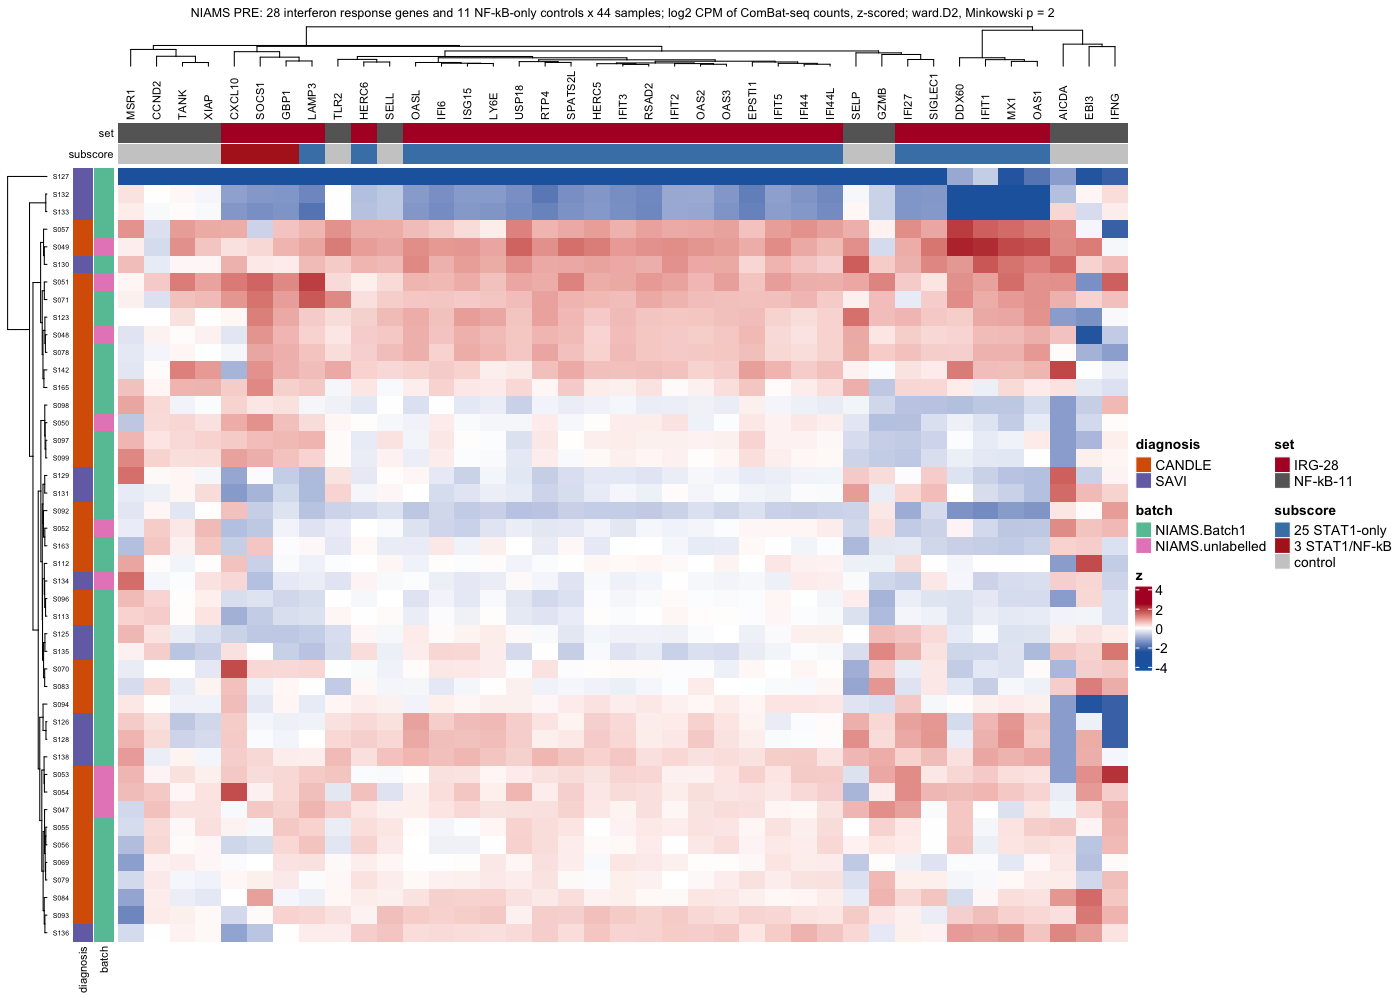

      diagnosis
branch CANDLE SAVI
     1     31   12
     2      0    1

$`1`
 [1] "CXCL10"  "EPSTI1"  "GBP1"    "HERC5"   "HERC6"   "IFI27"   "IFI44"  
 [8] "IFI44L"  "IFI6"    "IFIT2"   "IFIT3"   "IFIT5"   "ISG15"   "LAMP3"  
[15] "LY6E"    "OAS2"    "OAS3"    "OASL"    "RSAD2"   "RTP4"    "SIGLEC1"
[22] "SOCS1"   "SPATS2L" "USP18"   "CCND2"   "GZMB"    "MSR1"    "SELP"   
[29] "TANK"    "TLR2"    "SELL"    "XIAP"   

$`2`
[1] "DDX60" "IFIT1" "MX1"   "OAS1"  "AICDA" "EBI3"  "IFNG"

In [5]:
r <- ifn_heat(logcpm, left, "NIAMS PRE")
for (res in c(300, 100)) {                          # a 300 dpi PNG kept, a 100 dpi copy shown here
  f <- if (res == 300) fig("CANDLE_SAVI", "43_interferon_heatmap_NIAMS_PRE.png") else tempfile(fileext = ".png")
  png(f, width = 14, height = 10, units = "in", res = res); draw(r$ht); invisible(dev.off())
}
IRdisplay::display_png(file = f)
table(branch = cutree(r$rows, 2), diagnosis = pre$diagnosis)
split(r$genes$gene_name, cutree(r$cols, 2))

**Explanation**
- `ifn_heat()` draws the heatmap; it is saved at 300 dpi and shown at 100 dpi.
- `cutree(r$rows, 2)` gives the first split of the sample tree, crossed with the samples' labels;
  `cutree(r$cols, 2)` gives the first split of the gene tree, listed by branch.

**Result.** The first split of the gene tree puts 24 of the 28 interferon response genes with 8 controls, and
DDX60, IFIT1, MX1 and OAS1 with 3 controls (AICDA, EBI3, IFNG). The first split of the sample tree sets S127
apart (mean z of the 28 genes -4.87) from the other 43 (0.11). The median z of the 28 genes is 0.13 in CANDLE
and -0.15 in SAVI.